# PCA of the US Treasury Yield Curve vs Nelson-Siegel, 1982–2026

Can the data alone recover the level, slope and curvature that the Nelson-Siegel formula imposes? This notebook runs a principal component analysis (PCA) on eight US Treasury yields over 537 months, compares its components with the Nelson-Siegel factors, and repeats the analysis on monthly yield changes, the approach used in risk management.

**Contents:** 1. Setup · 2. Data · 3. Nelson-Siegel benchmark · 4. PCA on yield levels · 5. Loadings vs Nelson-Siegel · 6. Components vs Nelson-Siegel factors over time · 7. PCA on monthly changes · 8. Key findings

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from fredapi import Fred
from nelson_siegel_svensson.calibrate import betas_ns_ols

load_dotenv()
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

## 2. Data: US Treasury yields from the FRED API

Eight constant-maturity Treasury yields, from 3 months to 10 years, converted to monthly averages. These maturities are available without gaps since 1982.

In [2]:
# FRED code -> maturity in years
SERIES = {"DGS3MO": 0.25, "DGS6MO": 0.5, "DGS1": 1, "DGS2": 2,
          "DGS3": 3, "DGS5": 5, "DGS7": 7, "DGS10": 10}


def download_series(series, obs_start="1982-01-01", obs_end=None):
    """Télécharge les taux du Trésor depuis FRED et renvoie les moyennes mensuelles."""
    yields = {}
    for series_id in series:
        try:
            data = fred.get_series(series_id, observation_start=obs_start, observation_end=obs_end)
            if data is not None and not data.empty:
                yields[series_id] = data
        except Exception as e:
            print(f"[ERROR] {series_id}: {e}")

    if not yields:
        raise ValueError("Aucune donnée téléchargée.")

    monthly = pd.DataFrame(yields).resample("MS").mean().dropna()

    # Keep complete months only
    current_month = pd.Timestamp.today().to_period("M").to_timestamp()
    return monthly[monthly.index < current_month]


yields = download_series(SERIES)
print(yields.shape)
yields.info()



(537, 8)
<class 'pandas.DataFrame'>
DatetimeIndex: 537 entries, 1982-01-01 to 2026-09-01
Freq: MS
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DGS3MO  537 non-null    float64
 1   DGS6MO  537 non-null    float64
 2   DGS1    537 non-null    float64
 3   DGS2    537 non-null    float64
 4   DGS3    537 non-null    float64
 5   DGS5    537 non-null    float64
 6   DGS7    537 non-null    float64
 7   DGS10   537 non-null    float64
dtypes: float64(8)
memory usage: 37.8 KB


## 3. Nelson-Siegel benchmark

The Nelson-Siegel factors (β₀, β₁, β₂) are estimated every month with a fixed λ, exactly as in project 02. They serve as the benchmark for the principal components.

In [18]:
# λ fixed as in Diebold & Li (2006): 0.0609 in months, i.e. 0.7308 in years
LAMBDA = 0.7308
TAU = 1 / LAMBDA       
# Maturities in years, in column order
t = np.array(list(SERIES.values()))

# y = yields.loc[date].values

# Official US recessions (NBER, peak to trough)

RECESSIONS = [("1981-07-01", "1982-11-30"), ("1990-07-01", "1991-03-31"),
              ("2001-03-01", "2001-11-30"), ("2007-12-01", "2009-06-30"),
              ("2020-02-01", "2020-04-30")]


In [19]:
def fit_ns(y, tau=TAU):
    """Fit Nelson-Siegel (fixed λ) on one curve and return the curve and the fit error in basis points."""
    curve, _ = betas_ns_ols(tau, t, y)
    rmse_bp = np.sqrt(np.mean((y - curve(t)) ** 2)) * 100
    return curve, rmse_bp


def plot_ns_fit(t, y, curve, date, fig_num=1):
    """Plot the observed yields and the fitted Nelson-Siegel curve."""
    fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

    grid = np.linspace(0.25, 10, 200)
    ax.plot(t, y, marker='o', linestyle='none', markersize=8, label='Observed yields')
    ax.plot(grid, curve(grid), label='Nelson-Siegel fit')

    # Annotate each observed yield, slightly above the point
    
    for xi, yi in zip(t, y):
        ax.annotate(f"{yi:.2f}", (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)

    ax.set_xlabel('Maturity (years)')
    ax.set_ylabel('Yield (%)')
    ax.set_title(f"Figure {fig_num}, Observed vs Nelson-Siegel Fitted Yield Curve ({date[:7]})")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig



def fit_all_months(yields, tau=TAU):
    """Fit Nelson-Siegel on every month and return the factors and the fit error."""
    rows = []
    for date, row in yields.iterrows():
        curve, rmse_bp = fit_ns(row.values, tau)
        rows.append({
            "date": date,
            "beta0": curve.beta0,
            "beta1": curve.beta1,
            "beta2": curve.beta2,
            "rmse_bp": rmse_bp,
        })
    return pd.DataFrame(rows).set_index("date")

def shade_recessions(ax, start):
    """Shade recession periods on a chart."""
    for a, b in RECESSIONS:
        ax.axvspan(max(pd.Timestamp(a), start), pd.Timestamp(b), color="grey", alpha=0.25, lw=0)

In [20]:
yields = download_series(SERIES)
factors = fit_all_months(yields)

print(yields.shape, factors.shape)
yields.tail(3)

(537, 8) (537, 4)


,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10
2026-07-01,3.866818,4.001818,4.050909,4.222727,4.256818,4.330909,4.455455,4.599545
2026-08-01,3.876667,3.967619,4.031429,4.216190,4.282381,4.384286,4.524762,4.684286
2026-09-01,4.092857,4.178571,4.365238,4.651429,4.734762,4.802857,4.890952,4.989048


## 4. PCA on yield levels

Each month is a point with eight coordinates (the eight yields). PCA looks for the directions in which this cloud of 537 points stretches the most: yields are standardized, the eigenvectors and eigenvalues of their covariance matrix are extracted with `numpy.linalg.eigh` (designed for symmetric matrices), and the data are projected on the eigenvectors.

Since eigenvector signs are arbitrary, a sign convention makes each component easy to read: PC1 rises when all yields rise, PC2 when the curve steepens, PC3 when a hump appears in the middle of the curve.

In [6]:
def run_pca(data):
    """Run a PCA on standardized data and return loadings, explained variance and components."""
    standardized = (data - data.mean()) / data.std()
    cov = standardized.cov()                                # equals the correlation matrix of the raw data

    eigenvalues, eigenvectors = np.linalg.eigh(cov)         # eigh is designed for symmetric matrices
    order = np.argsort(eigenvalues)[::-1]                   # sort from largest to smallest
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    names = [f"PC{i + 1}" for i in range(len(eigenvalues))]
    loadings = pd.DataFrame(eigenvectors, index=data.columns, columns=names)

    # Eigenvector signs are arbitrary: orient them so that each component is easy to read
    if loadings["PC1"].mean() < 0:                                          # PC1 up = all yields up
        loadings["PC1"] *= -1
    if loadings.loc["DGS10", "PC2"] < loadings.loc["DGS3MO", "PC2"]:        # PC2 up = steeper curve
        loadings["PC2"] *= -1
    hump = loadings.loc["DGS2", "PC3"] - (loadings.loc["DGS3MO", "PC3"] + loadings.loc["DGS10", "PC3"]) / 2
    if hump < 0:                                                            # PC3 up = hump in the middle
        loadings["PC3"] *= -1

    components = standardized @ loadings
    explained = pd.Series(eigenvalues / eigenvalues.sum(), index=names)
    return loadings, explained, components

In [21]:
loadings, explained, pcs = run_pca(yields)

variance_table = pd.DataFrame({"Explained": explained, "Cumulative": explained.cumsum()})
(variance_table.head(4) * 100).round(2).add_suffix(" (%)")

,Explained (%),Cumulative (%)
PC1,97.68,97.68
PC2,2.17,99.86
PC3,0.12,99.98
PC4,0.02,99.99


In [22]:
loadings[["PC1", "PC2", "PC3"]].round(3)

,PC1,PC2,PC3
DGS3MO,0.350,-0.479,-0.548
DGS6MO,0.352,-0.412,-0.143
DGS1,0.355,-0.294,0.232
DGS2,0.357,-0.075,0.454
DGS3,0.357,0.064,0.429
DGS5,0.355,0.280,0.132
DGS7,0.353,0.404,-0.132
DGS10,0.349,0.514,-0.448


### PCA on yield levels: explained variance and loadings

| Component | Explained | Cumulative |
|-----------|-----------|------------|
| PC1 | 97.68% | 97.68% |
| PC2 | 2.17% | 99.86% |
| PC3 | 0.12% | 99.98% |

**Three components capture 99.98% of the variation** in the eight yields over 537 months. PC1 dominates even more than in shorter samples (about 84% from 2001 onwards in comparable studies) because the 1982–2026 period is driven by one huge common move: the four-decade fall in rates, then the rebound.

**The loadings reveal three familiar shapes, found by the data alone:**
- **PC1 (level):** all loadings are close to 0.35. Since an eigenvector has unit length, equal weights on eight maturities would be 1/√8 ≈ 0.354: PC1 is a pure parallel shift.
- **PC2 (slope):** loadings rise steadily from −0.48 (3 months) to +0.51 (10 years), changing sign around 2–3 years. When PC2 rises, the curve steepens.
- **PC3 (curvature):** negative at both ends (−0.55 and −0.45), positive in the middle, with a peak at 2–3 years. A hump.

**A striking match:** the PC3 hump peaks around 2.5 years, exactly where the Nelson-Siegel curvature loading peaks with the fixed λ = 0.7308 used in project 02. The data place the hump where Diebold and Li placed theirs.

**Caveat:** on yield *levels*, which trend over decades, PCA mechanically gives a very large weight to PC1. Section 5 repeats the analysis on monthly *changes*, the standard approach in risk management.

## 5. PCA loadings vs Nelson-Siegel loadings

For each factor, the PCA loading (found by the data alone) is plotted against the matching Nelson-Siegel loading (imposed by the formula). To compare shapes rather than scales, the Nelson-Siegel loadings are rescaled to unit length; the slope and curvature loadings are also centred, since their constant part is already carried by the level. Similarity is measured by the cosine between the two unit vectors (1 = identical shapes).

In [23]:
def ns_loadings(maturities, lam=LAMBDA):
    """Return the Nelson-Siegel loadings (level, slope, curvature) at the given maturities."""
    m = np.asarray(maturities, dtype=float)
    slope = (1 - np.exp(-lam * m)) / (lam * m)
    curvature = slope - np.exp(-lam * m)
    return np.ones_like(m), slope, curvature


def plot_loadings_vs_ns(loadings, t, fig_num=1):
    """Compare PCA loadings with Nelson-Siegel loadings, rescaled to compare shapes."""
    grid = np.linspace(0.25, 10, 200)
    ns_points, ns_grid = ns_loadings(t), ns_loadings(grid)
    specs = [("PC1", "Level", 1, "tab:blue"),
             ("PC2", "Slope", -1, "tab:orange"),       # flipped: PC2 rises when the curve steepens
             ("PC3", "Curvature", 1, "tab:purple")]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=200, sharey=True)
    for ax, (pc, name, sign, color), lt, lg in zip(axes, specs, ns_points, ns_grid):
        # Remove the constant part (already carried by the level), except for the level itself
        mean = 0 if name == "Level" else lt.mean()
        norm = np.linalg.norm(lt - mean)
        ns_shape = sign * (lt - mean) / norm
        similarity = float(ns_shape @ loadings[pc].values)

        ax.plot(grid, sign * (lg - mean) / norm, color="grey", lw=2, label="Nelson-Siegel (rescaled)")
        ax.plot(t, loadings[pc], marker="o", linestyle="none", markersize=7, color=color, label=f"PCA {pc}")
        ax.axhline(0, color="black", lw=0.8, ls="--")
        ax.set_title(f"{name}: {pc} vs Nelson-Siegel\nCosine similarity = {similarity:.3f}", fontsize=10)
        ax.set_xlabel("Maturity (years)")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    axes[0].set_ylabel("Loading (unit length)")
    fig.suptitle(f"Figure {fig_num}, PCA Loadings vs Nelson-Siegel Loadings (λ = {LAMBDA})")
    fig.tight_layout()
    return fig

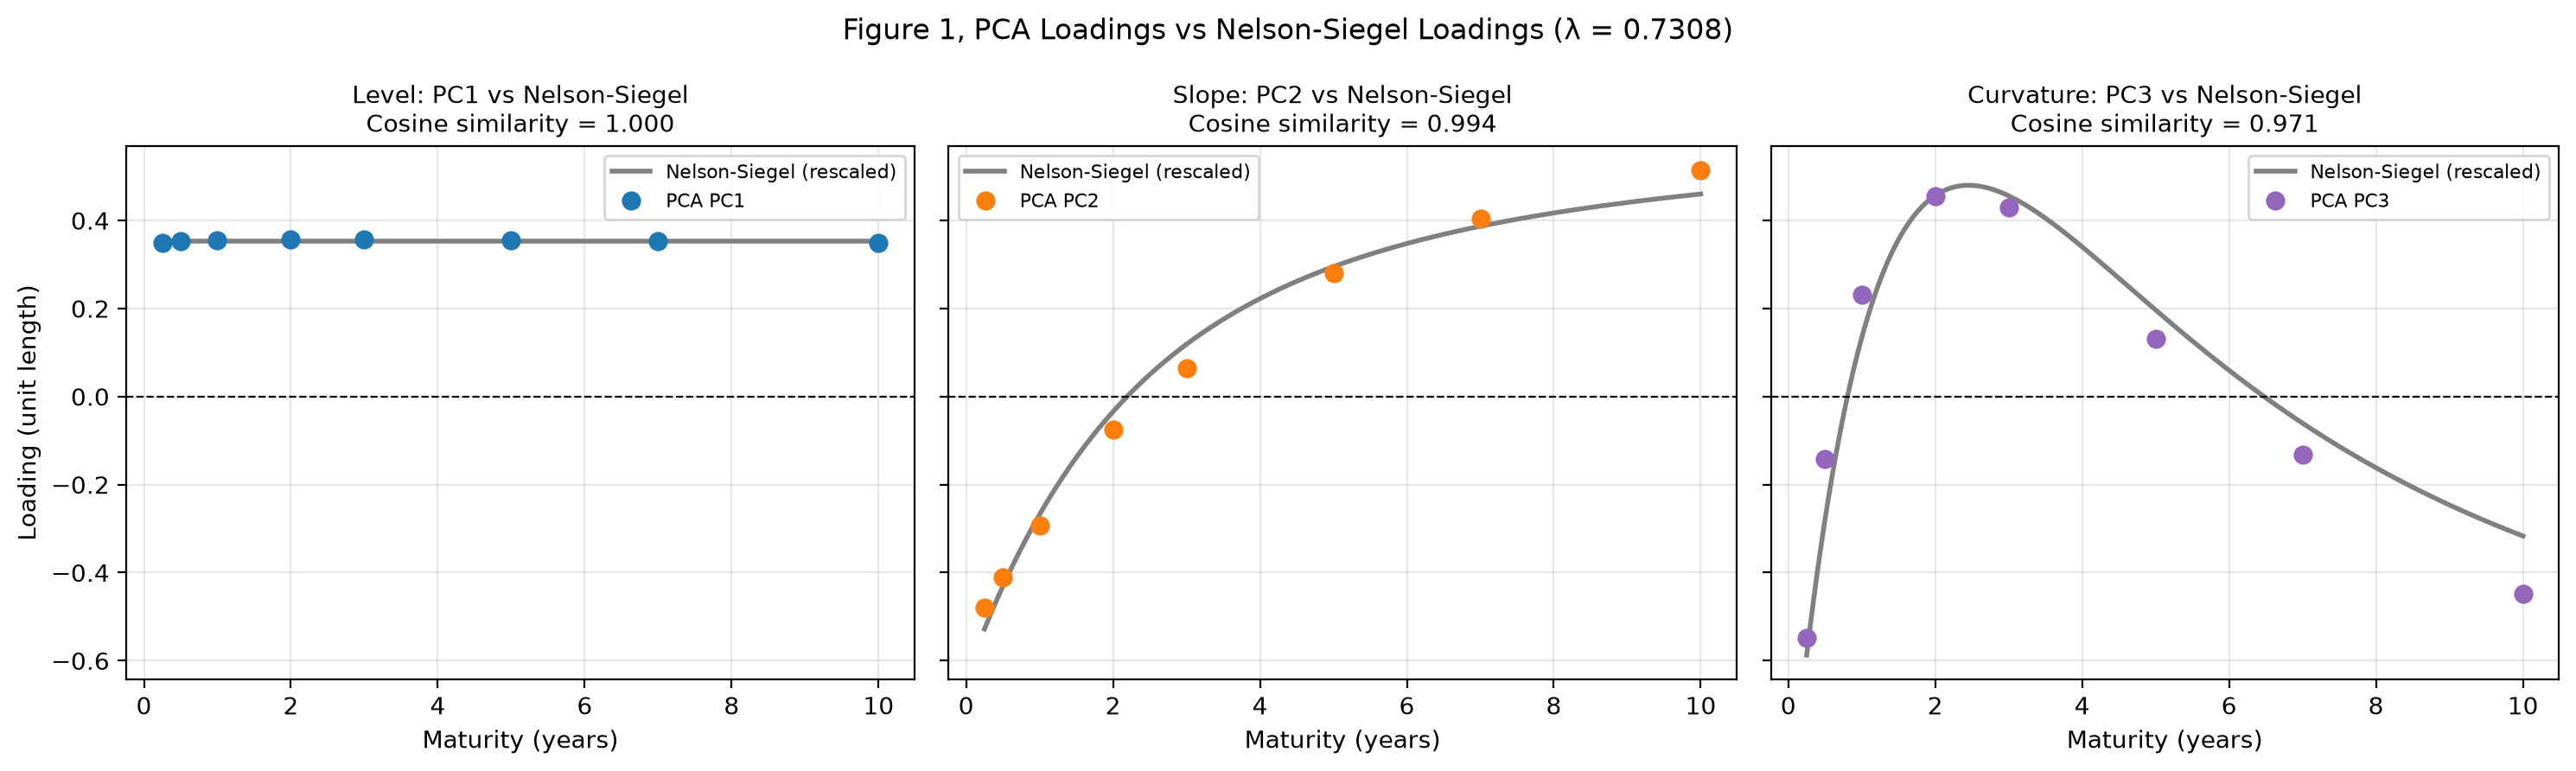

In [10]:
fig = plot_loadings_vs_ns(loadings, t)
fig.savefig("assets/figure1_loadings_vs_ns.png", bbox_inches="tight")
plt.show()

### PCA loadings vs Nelson-Siegel loadings (Figure 1)

Each panel compares a PCA loading (dots, found by the data alone) with the matching Nelson-Siegel loading (grey line, imposed by the formula with λ = 0.7308). To compare shapes rather than scales, the Nelson-Siegel loadings are rescaled to unit length; the slope and curvature loadings are also centred, since their constant part is already carried by the level. Similarity is measured by the cosine between the two unit vectors (1 = identical shapes).

| Factor | Cosine similarity |
|--------|-------------------|
| Level (PC1) | 1.000 |
| Slope (PC2) | 0.994 |
| Curvature (PC3) | 0.971 |

- **Level:** a perfect match. PC1 is a flat line, exactly like the Nelson-Siegel level loading.
- **Slope:** an almost perfect match. The data slope is slightly lower around 2–3 years and slightly higher at 10 years than the formula.
- **Curvature:** a very close match, with the hump peaking at the same place (2–3 years). Beyond 5 years, however, the PCA loading falls faster and further than the Nelson-Siegel one (−0.45 against about −0.32 at 10 years).

**Interpretation:** with a single λ, the Nelson-Siegel curvature loading decays slowly after its hump. The data suggest that the long end moves somewhat more independently than the formula allows, the limitation that led Svensson to add a second hump to the model. Without being told anything about finance, PCA recovers the three Nelson-Siegel shapes, and even points to the model's best-known limitation.

## 6. Principal components vs Nelson-Siegel factors over time

Section 5 compared shapes; this section compares histories. Each component is paired with its Nelson-Siegel factor in the same orientation (PC2 with −β₁, since PC2 rises when the curve steepens), and both series are shown as z-scores to share a common scale.

In [24]:
def pair_pcs_with_ns(pcs, factors):
    """Pair each principal component with the matching Nelson-Siegel factor, in the same orientation."""
    return {
        "Level": (pcs["PC1"], factors["beta0"], "β₀"),
        "Slope": (pcs["PC2"], -factors["beta1"], "−β₁"),        # PC2 rises when the curve steepens
        "Curvature": (pcs["PC3"], factors["beta2"], "β₂"),
    }


def zscore(series):
    """Standardize a series to mean 0 and standard deviation 1."""
    return (series - series.mean()) / series.std()


def plot_pcs_vs_ns(pcs, factors, fig_num=2):
    """Plot each principal component against its Nelson-Siegel factor over time (z-scores)."""
    pairs = pair_pcs_with_ns(pcs, factors)
    colors = ["tab:blue", "tab:orange", "tab:purple"]

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), dpi=200, sharex=True)
    for ax, (name, (pc, factor, label)), color in zip(axes, pairs.items(), colors):
        corr = pc.corr(factor)
        ax.plot(pc.index, zscore(pc), color=color, label=f"{pc.name} (PCA)")
        ax.plot(factor.index, zscore(factor), color="black", lw=1, ls="--", label=f"{label} (Nelson-Siegel)")
        shade_recessions(ax, pc.index[0])
        ax.set_ylabel(f"{name} (z-score)")
        ax.set_title(f"{name}: correlation = {corr:.3f}", fontsize=10, loc="left")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    axes[0].set_title(f"Figure {fig_num}, Principal Components vs Nelson-Siegel Factors (grey = NBER recessions)")
    axes[-1].set_xlabel("Date")
    fig.tight_layout()
    return fig

In [25]:
pairs = pair_pcs_with_ns(pcs, factors)
pd.DataFrame({name: [pc.corr(factor)] for name, (pc, factor, _) in pairs.items()},
             index=["Correlation"]).round(3)

,Level,Slope,Curvature
Correlation,0.933,0.993,0.656


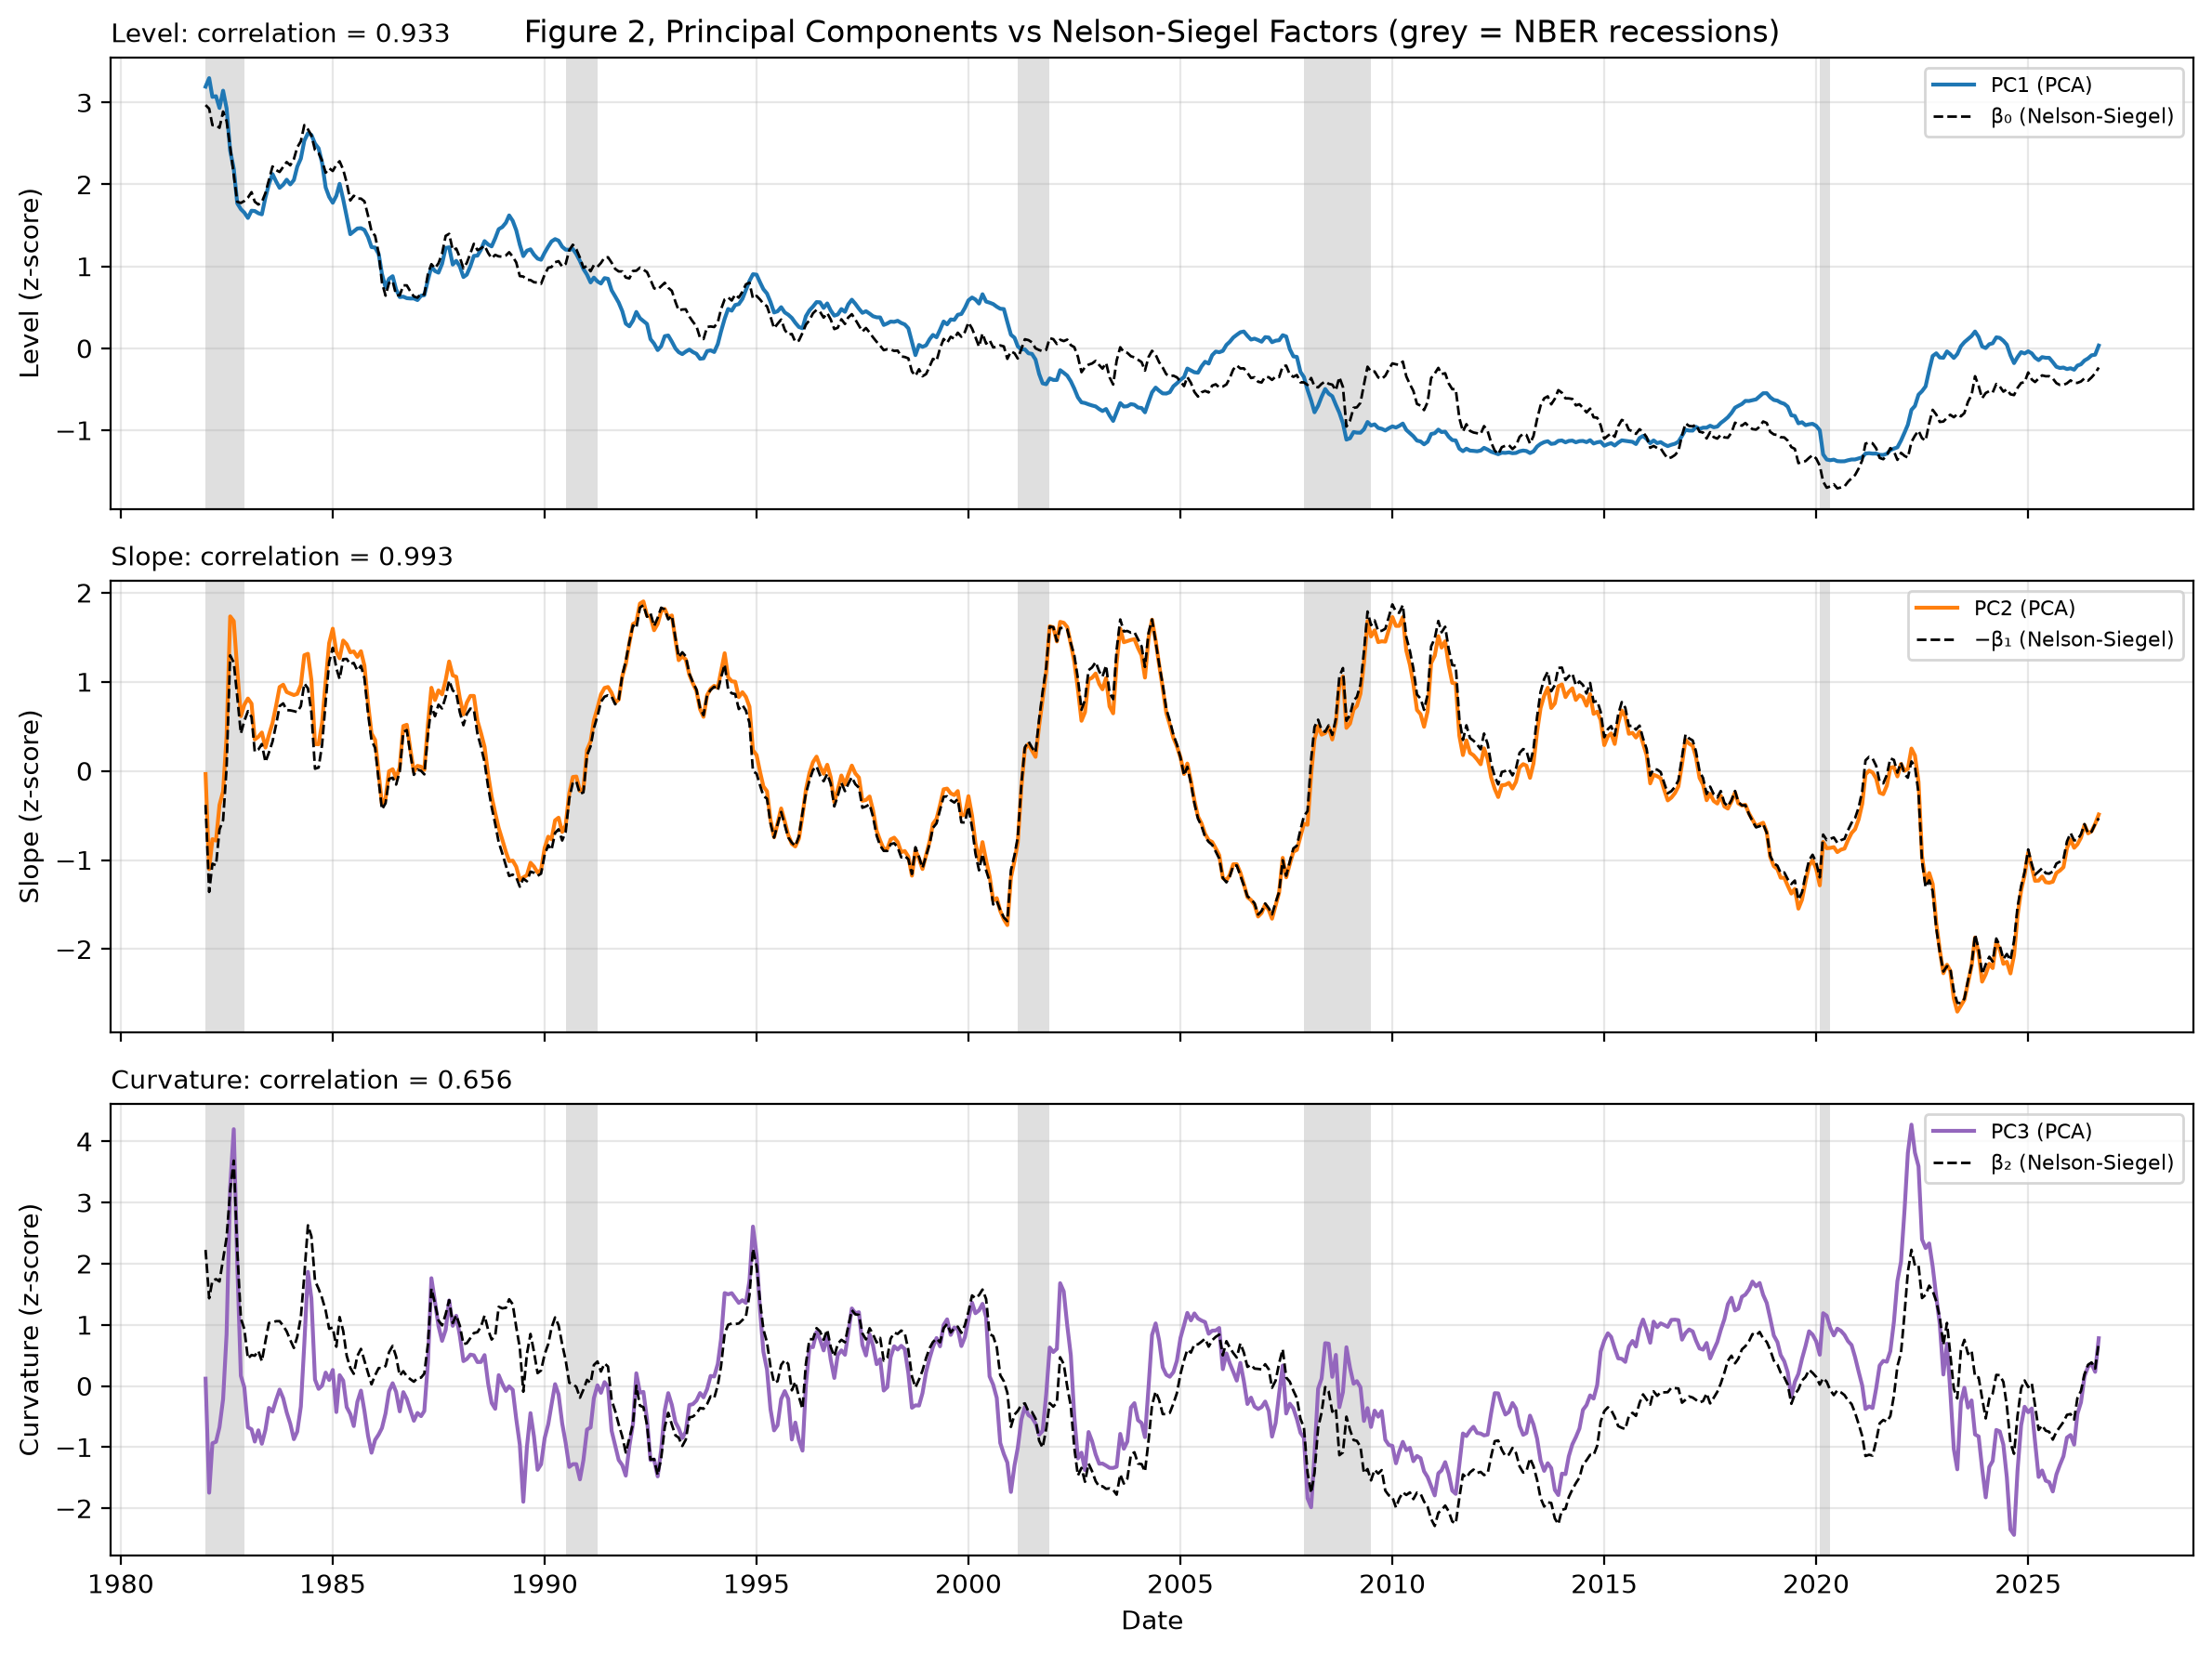

In [26]:
fig = plot_pcs_vs_ns(pcs, factors)
fig.savefig("assets/figure2_pcs_vs_ns.png", bbox_inches="tight")
plt.show()

### Principal components vs Nelson-Siegel factors over time (Figure 2)

Each component is compared with its Nelson-Siegel counterpart in the same orientation (PC2 with −β₁, since PC2 rises when the curve steepens). Both series are shown as z-scores to share a common scale.

| Factor | Correlation |
|--------|-------------|
| Level (PC1 vs β₀) | 0.933 |
| Slope (PC2 vs −β₁) | 0.993 |
| Curvature (PC3 vs β₂) | 0.656 |

**Slope (0.993):** the two series are almost indistinguishable over 44 years. PCA and Nelson-Siegel measure exactly the same thing.

**Level (0.933):** very high but not perfect, and the gaps are informative. From 2009 to 2015, β₀ sits above PC1; from 2022 to 2025, the opposite. PC1 weights all eight maturities equally, so it is an *average* level of the curve, while β₀ is the *very long-term* yield. When short rates are stuck at zero, the average is pulled down; when the curve is deeply inverted, high short rates pull it up. The gap between the two level measures therefore reflects the slope.

**Curvature (0.656):** clearly weaker, for three reasons. PC3 explains only 0.12% of the variance, which makes it sensitive to noise. Its loading differs from the Nelson-Siegel one at the long end (Figure 1), and on such a small factor this is enough to make the series diverge. Finally, principal components are uncorrelated by construction, while Nelson-Siegel factors are not: β₂ can carry some slope information that PC3 does not. Both series still agree on the major episodes: 1982, 1995 and the 2022 spike during the fastest Fed hiking cycle in 40 years.

**Takeaway:** a near-identical shape (0.971 in Figure 1) does not guarantee near-identical series. The smaller the factor, the more small differences in shape weigh on its history.

## 7. PCA on monthly yield changes

Risk managers apply PCA to yield *changes* rather than levels: changes are what make a bond portfolio gain or lose money, and they are free of the decades-long trend that inflates PC1 on levels. The same PCA is repeated on month-to-month changes.

In [27]:
def plot_loadings_levels_vs_changes(loadings_lvl, loadings_chg, t, fig_num=3):
    """Compare the first three PCA loadings estimated on yield levels and on monthly changes."""
    names = [("PC1", "Level"), ("PC2", "Slope"), ("PC3", "Curvature")]
    colors = ["tab:blue", "tab:orange", "tab:purple"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=200, sharey=True)
    for ax, (pc, name), color in zip(axes, names, colors):
        ax.plot(t, loadings_lvl[pc], marker="o", color=color, label="Levels")
        ax.plot(t, loadings_chg[pc], marker="s", color="black", ls="--", label="Monthly changes")
        ax.axhline(0, color="black", lw=0.8, ls=":")
        ax.set_title(f"{name} ({pc})", fontsize=10)
        ax.set_xlabel("Maturity (years)")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    axes[0].set_ylabel("Loading (unit length)")
    fig.suptitle(f"Figure {fig_num}, PCA Loadings: Yield Levels vs Monthly Changes")
    fig.tight_layout()
    return fig

In [28]:
changes = yields.diff().dropna()                     # monthly changes, in percentage points
loadings_chg, explained_chg, pcs_chg = run_pca(changes)

comparison = pd.DataFrame({
    "Levels (%)": explained * 100,
    "Levels cumulative (%)": explained.cumsum() * 100,
    "Changes (%)": explained_chg * 100,
    "Changes cumulative (%)": explained_chg.cumsum() * 100,
}).head(4).round(2)
comparison

,Levels (%),Levels cumulative (%),Changes (%),Changes cumulative (%)
PC1,97.68,97.68,84.41,84.41
PC2,2.17,99.86,12.89,97.30
PC3,0.12,99.98,1.75,99.05
PC4,0.02,99.99,0.59,99.64


In [29]:
loadings_chg[["PC1", "PC2", "PC3"]].round(3)

,PC1,PC2,PC3
DGS3MO,0.290,-0.613,-0.502
DGS6MO,0.340,-0.446,-0.032
DGS1,0.367,-0.240,0.360
DGS2,0.378,0.011,0.461
DGS3,0.376,0.137,0.325
DGS5,0.367,0.282,-0.033
DGS7,0.357,0.352,-0.265
DGS10,0.346,0.382,-0.478


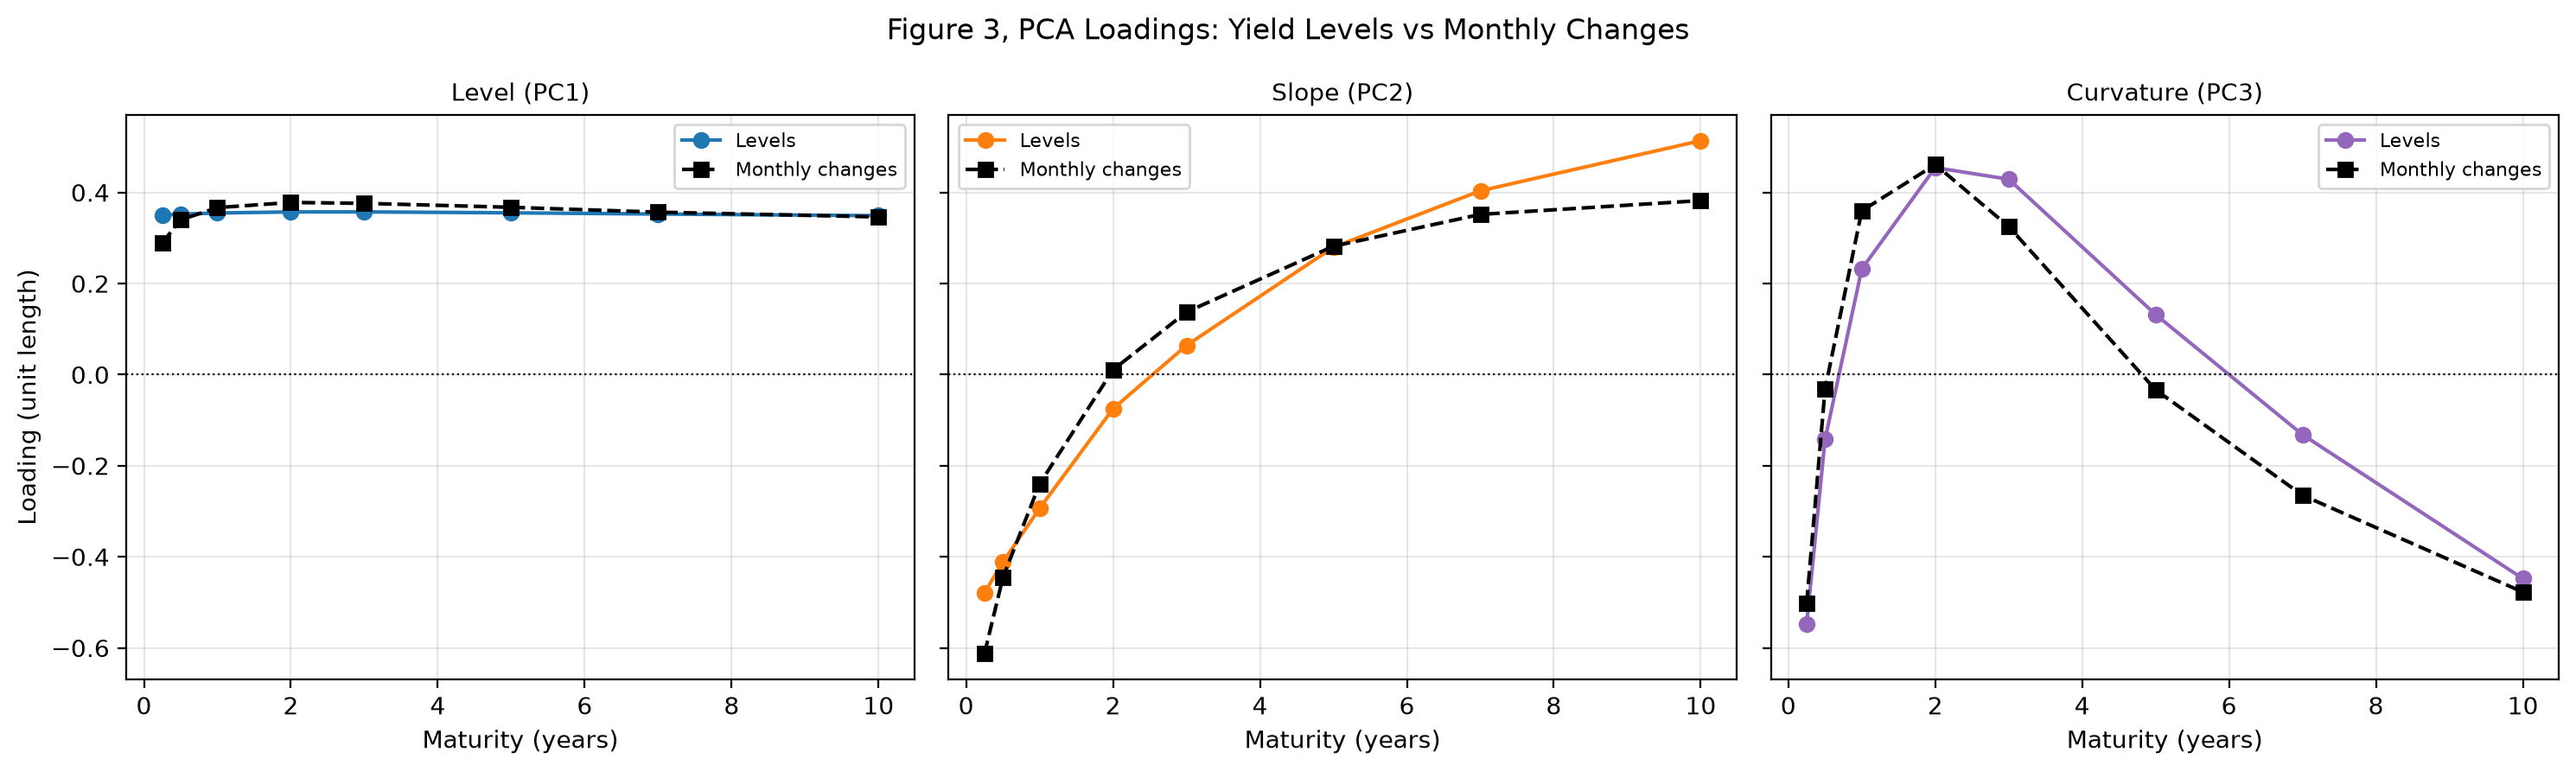

In [30]:
fig = plot_loadings_levels_vs_changes(loadings, loadings_chg, t)
fig.savefig("assets/figure3_levels_vs_changes.png", bbox_inches="tight")
plt.show()

 

### PCA on monthly yield changes (Figure 3)

Risk managers apply PCA to yield *changes* rather than levels: changes are what make a bond portfolio gain or lose money, and they are free of the decades-long trend that inflates PC1 on levels.

| Component | Levels | Levels (cum.) | Changes | Changes (cum.) |
|-----------|--------|---------------|---------|----------------|
| PC1 | 97.68% | 97.68% | 84.41% | 84.41% |
| PC2 | 2.17% | 99.86% | 12.89% | 97.30% |
| PC3 | 0.12% | 99.98% | 1.75% | 99.05% |

**Three factors are still enough:** they explain 99% of monthly moves, the classic result of Litterman and Scheinkman (1991), found here over 44 years. **But slope and curvature matter far more:** together about 15% of monthly moves, against barely 2% on levels. In practice, hedging only parallel shifts (duration) leaves about 15% of monthly yield-curve moves unhedged.

**The loadings keep the same three shapes, with telling nuances:**
- **Level (PC1)** is no longer perfectly flat: the 3-month yield has the lowest weight (0.29) and the 2–3 year maturities the highest (0.38). The short end partly moves for its own reasons, such as Fed decisions or flights to safety.
- **Slope (PC2)** is more concentrated at the short end (−0.61 at 3 months against −0.48 on levels), and pivots exactly at 2 years: month-to-month slope changes come mostly from the front end, where the Fed acts.
- **Curvature (PC3)** has a narrower hump, still peaking at 2 years but turning negative around 5 years (about 6 years on levels): curvature shocks are concentrated on the 1–3 year segment.

**Takeaway:** the same three shapes appear whether we look at levels or changes. Two different angles, one structure: level, slope and curvature are the real forces that move the yield curve.

## 8. Key findings

| # | Finding | Evidence |
|---|---------|----------|
| 1 | **The data alone recover the Nelson-Siegel shapes** | Cosine similarity between PCA and Nelson-Siegel loadings: level 1.000, slope 0.994, curvature 0.971; the PC3 hump peaks around 2.5 years, exactly where the Nelson-Siegel curvature peaks with λ = 0.7308 (Figure 1) |
| 2 | **Three factors explain almost everything** | 99.98% of the variance of yield levels and 99.05% of monthly yield changes over 537 months |
| 3 | **Yield levels overstate the level factor** | PC1 explains 97.68% of levels but 84.41% of monthly changes; slope and curvature account for about 15% of monthly moves against about 2% of levels, so a duration-only hedge leaves about 15% of monthly curve moves unhedged (Figure 3) |
| 4 | **The slope is the most robust factor** | PC2 and −β₁ are almost identical over 44 years: correlation 0.993 (Figure 2) |
| 5 | **Two different notions of "level"** | PC1 (average level) and β₀ (very long-term level) correlate at 0.933; their gaps in 2009–2015 (zero rates) and 2022–2025 (deep inversion) reflect the slope |
| 6 | **Curvature is the fragile factor** | PC3 explains only 0.12% of levels; its correlation with β₂ drops to 0.656, and its loading falls faster at the long end than the Nelson-Siegel one, the limitation that led Svensson to add a second hump |
| 7 | **The short end lives its own life** | On monthly changes, the 3-month yield has the lowest level loading (0.29) and the strongest slope loading (−0.61): the front end, where the Fed acts, moves partly on its own |

**Takeaway:** a purely statistical method, knowing nothing about finance, finds the same three forces as the Nelson-Siegel formula: level, slope and curvature. Level and slope are robust whichever way they are measured; curvature is real but small and fragile. For risk management, the lesson is clear: the yield curve moves in three dimensions, not one.